# D209 Task 2 Performance Assessment

## Part I: Research Question

### A. Describe the purpose of this data mining report by doing the following:

#### 1. Propose one question relevant to a real-world organizational situation that you will answer using one of the following prediction methods: decision trees, random forests, advanced regression (i.e., lasso or ridge regression)

One research question relevant to a real-world organizational situation that I will answer using a decision tree classifier is, "Can we use a Decision Tree Classification model to predict whether a patient will be readmitted within one month of release based on the available data?"

#### 2. Define one goal of the data analysis. Ensure that your goal is reasonable within the scope of the scenario and is represented in the available data.

One goal of the data analysis is to build and evaluate an adaptive boosted decision tree classifier to help the organization predict whether a patient will be readmitted within one month of release. Doing so will require data preprocessing and assessment of model evaluation statistics. Ideally, the classifier will be successful at predicting whether patients will be readmitted within one month of release.

## Part II: Method Justification

### B. Explain the reasons for your chosen prediction method from part A1 by doing the following:

#### 1. Explain how the prediction method you chose analyzes the selected data set. Include expected outcomes.

According to Sehra (2018), "Decision Trees (DTs) are a non-parametric supervised learning method used for classification and regression. Decision trees learn from data to approximate a sine curve with a set of if-then-else decision rules. The deeper the tree, the more complex the decision rules and the fitter the model."

Additionally, Sehra (2018) notes "Decision tree builds classification or regression models in the form of a tree structure. It breaks down a dataset into smaller and smaller subsets while at the same time an associated decision tree is incrementally developed. The final result is a tree with decision nodes and leaf nodes. A decision node has two or more branches. Leaf node represents a classification or decision. The topmost decision node in a tree which corresponds to the best predictor called root node. Decision trees can handle both categorical and numerical data."

In addition to the above, it is important to note that a decision tree is not sensitive to outliers and, unlike the KNN classification method from task 1, does not require feature scaling. In essence, the decision tree splits the data into small subsets based on certain conditions. Those subsets, or branches, can be traversed to predict the class label for the unknown instance that meets a set of specific criteria. For example, a car could have subsets based on make, model, paint color, transmission type, year of manufacture, etc. From there, the tree could look at, say, a 1995 manual transmission red Mazda Miata and predict whether these attributes would likely lead to buying the car or not buying the car.

#### 2. Summarize one assumption of the chosen prediction method.

One assumption of a decision tree algorithm is that the decision tree algorithm is non-parametric. According to pantelis (n.d.), "They are non-parametric models because they don’t need a predetermined set of parameters before training can start as in parametric models - rather the tree fits the data very closely and often overfits using as many parameters are required during training."  The decision tree being non-parametric has several benefits and pitfalls. One benefit is that by not making distribution assumptions about the data, decision trees are more flexible in terms of what relationships they can model. However, as pantelis noted above, if the decision tree grows too deep, it may become prone to overfitting. As such, it will be important to correctly set the parameter for maximum depth for the model.

#### 3. List the packages or libraries you have chosen for Python or R, and justify how each item on the list supports the analysis.

The following packages or libraries were used to support the analysis:

Pandas: Used to read in the initial CSV file and to perform one-hot encoding

Train_test_split: Used to split the data into X and y training and testing sets

DecisionTreeClassifier: Used to implement the decision tree classification algorithm

GridSearchCV: Used for cross-validating the decision tree classifier as part of hyperparameter tuning

Roc_auc_score: Used to generate the AUC score for the decision tree classifier, which allows for assessment of model performance

Confusion_matrix: Used to generate the confusion matrix for the decision tree classifier, which allows for further assessment of model performance

Mean_squared_error: Used to generate the mean squared error for the model, which allows for additional assessment of model performance

Classification_report: Creates a report of model performance which can be used to see how well the model performs

Roc_curve: Used to help create a visualization of the ROC Curve

Accuracy_score: Used to generate the accuracy score which helps with assessing the initial Decision Tree performance

Matplotlib.pyplot: Used to plot the ROC curve

## Part III: Data Preparation

### C. Perform data preparation for the chosen data set by doing the following:

#### 1. Describe one data preprocessing goal relevant to the prediction method from part A1.

One data preprocessing goal relevant to the decision tree classifier is re-encoding of categorical variables. Although the decision tree classifier requires fewer preprocessing steps than the k-nearest neighbors classifier did (primarily feature scaling), as the decision tree classifier is a machine learning model, it requires the data to be numerical. As such, the 'value_counts()' function will be used on categorical variables to determine whether the variable should be ordinally encoded or one-hot encoded. Ordinal encoding will be done using the 'replace()' method, while one-hot encoding will be performed using 'get_dummies()'. Once this has been performed, the dataframe will be checked to determine if all the remaining variables are numeric, which will be necessary in order for the decision tree classifier to function correctly.

#### 2. Identify the initial data set variables that you will use to perform the analysis for the prediction question from part A1, and group each variable as numeric or categorical.

The initial data set variables that I will use to perform the analysis for the prediction question from part A1 are noted below. The unkept variables were not kept due to being a patient ID, difficult to work with demographic data (that did not seem like it could provide much helpful insight such as Zip, Population, or Job), or survey response data (which seemed unwieldy to work with in order to produce any results).

| Variable | Category |
| --- | --- |
| Children | Numeric |
| Age | Numeric |
| Income | Numeric |
| VitD_levels | Numeric |
| Doc_visits | Numeric |
| Full_meals_eaten | Numeric |
| vitD_supp | Numeric |
| Initial_days | Numeric |
| TotalCharge | Numeric |
| Additional_charges | Numeric |
| Area | Categorical |
| Marital | Categorical |
| Gender | Categorical |
| ReAdmis | Categorical |
| Soft_drink | Categorical |
| Initial_admin | Categorical |
| HighBlood | Categorical |
| Stroke | Categorical |
| Complication_risk | Categorical |
| Overweight | Categorical |
| Arthritis | Categorical |
| Diabetes | Categorical |
| Hyperlipidemia | Categorical |
| BackPain | Categorical |
| Anxiety | Categorical |
| Allergic_rhinitis | Categorical |
| Reflux_esophagitis | Categorical |
| Asthma | Categorical |
| Services | Categorical |

#### 3. Explain the steps used to prepare the data for the analysis. Identify the code segment for each step.

<b>Read in file and look at the data:</b>

In [76]:
#Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, confusion_matrix, mean_squared_error, classification_report, roc_curve, accuracy_score 
import matplotlib.pyplot as plt

#Question C3 - Data preprocessing for Decision Tree Classifier

#Read in file
file = "medical_clean.csv"
medical_data = pd.read_csv(file)

#View the data
medical_data.head()

,CaseOrder,Customer_id,Interaction,UID,City,State,County,Zip,Lat,Lng,...,TotalCharge,Additional_charges,Item1,Item2,Item3,Item4,Item5,Item6,Item7,Item8
0,1,C412403,8cd49b13-f45a-4b47-a2bd-173ffa932c2f,3a83ddb66e2ae73798bdf1d705dc0932,Eva,AL,Morgan,35621,34.34960,-86.72508,...,3726.702860,17939.403420,3,3,2,2,4,3,3,4
1,2,Z919181,d2450b70-0337-4406-bdbb-bc1037f1734c,176354c5eef714957d486009feabf195,Marianna,FL,Jackson,32446,30.84513,-85.22907,...,4193.190458,17612.998120,3,4,3,4,4,4,3,3
2,3,F995323,a2057123-abf5-4a2c-abad-8ffe33512562,e19a0fa00aeda885b8a436757e889bc9,Sioux Falls,SD,Minnehaha,57110,43.54321,-96.63772,...,2434.234222,17505.192460,2,4,4,4,3,4,3,3
3,4,A879973,1dec528d-eb34-4079-adce-0d7a40e82205,cd17d7b6d152cb6f23957346d11c3f07,New Richland,MN,Waseca,56072,43.89744,-93.51479,...,2127.830423,12993.437350,3,5,5,3,4,5,5,5
4,5,C544523,5885f56b-d6da-43a3-8760-83583af94266,d2f0425877b10ed6bb381f3e2579424a,West Point,VA,King William,23181,37.59894,-76.88958,...,2113.073274,3716.525786,2,1,3,3,5,3,4,3


<b>Duplicate check and missing value check:</b>

In [77]:
#Duplicate check
print(medical_data.duplicated().value_counts())

False    10000
Name: count, dtype: int64


In [78]:
#Missing value check
print(medical_data.isnull().sum())

#Outlier detection not needed as DT classifier is not sensitive to outliers

CaseOrder             0
Customer_id           0
Interaction           0
UID                   0
City                  0
State                 0
County                0
Zip                   0
Lat                   0
Lng                   0
Population            0
Area                  0
TimeZone              0
Job                   0
Children              0
Age                   0
Income                0
Marital               0
Gender                0
ReAdmis               0
VitD_levels           0
Doc_visits            0
Full_meals_eaten      0
vitD_supp             0
Soft_drink            0
Initial_admin         0
HighBlood             0
Stroke                0
Complication_risk     0
Overweight            0
Arthritis             0
Diabetes              0
Hyperlipidemia        0
BackPain              0
Anxiety               0
Allergic_rhinitis     0
Reflux_esophagitis    0
Asthma                0
Services              0
Initial_days          0
TotalCharge           0
Additional_charg

<b>Summary statistics:</b>

In [79]:
medical_data['Children'].describe()

count    10000.000000
mean         2.097200
std          2.163659
min          0.000000
25%          0.000000
50%          1.000000
75%          3.000000
max         10.000000
Name: Children, dtype: float64

In [80]:
medical_data['Age'].describe()

count    10000.000000
mean        53.511700
std         20.638538
min         18.000000
25%         36.000000
50%         53.000000
75%         71.000000
max         89.000000
Name: Age, dtype: float64

In [81]:
medical_data['Income'].describe()

count     10000.000000
mean      40490.495160
std       28521.153293
min         154.080000
25%       19598.775000
50%       33768.420000
75%       54296.402500
max      207249.100000
Name: Income, dtype: float64

In [82]:
medical_data['VitD_levels'].describe()

count    10000.000000
mean        17.964262
std          2.017231
min          9.806483
25%         16.626439
50%         17.951122
75%         19.347963
max         26.394449
Name: VitD_levels, dtype: float64

In [83]:
medical_data['Doc_visits'].describe()

count    10000.000000
mean         5.012200
std          1.045734
min          1.000000
25%          4.000000
50%          5.000000
75%          6.000000
max          9.000000
Name: Doc_visits, dtype: float64

In [84]:
medical_data['Full_meals_eaten'].describe()

count    10000.000000
mean         1.001400
std          1.008117
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max          7.000000
Name: Full_meals_eaten, dtype: float64

In [85]:
medical_data['vitD_supp'].describe()

count    10000.000000
mean         0.398900
std          0.628505
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          5.000000
Name: vitD_supp, dtype: float64

In [86]:
medical_data['Initial_days'].describe()

count    10000.000000
mean        34.455299
std         26.309341
min          1.001981
25%          7.896215
50%         35.836244
75%         61.161020
max         71.981490
Name: Initial_days, dtype: float64

In [87]:
medical_data['TotalCharge'].describe()

count    10000.000000
mean      5312.172769
std       2180.393838
min       1938.312067
25%       3179.374015
50%       5213.952000
75%       7459.699750
max       9180.728000
Name: TotalCharge, dtype: float64

In [88]:
medical_data['Additional_charges'].describe()

count    10000.000000
mean     12934.528587
std       6542.601544
min       3125.703000
25%       7986.487755
50%      11573.977735
75%      15626.490000
max      30566.070000
Name: Additional_charges, dtype: float64

In [89]:
medical_data['Area'].value_counts() #One-hot

Area
Rural       3369
Suburban    3328
Urban       3303
Name: count, dtype: int64

In [90]:
medical_data['Marital'].value_counts() #One-hot

Marital
Widowed          2045
Married          2023
Separated        1987
Never Married    1984
Divorced         1961
Name: count, dtype: int64

In [91]:
medical_data['Gender'].value_counts() #One-hot

Gender
Female       5018
Male         4768
Nonbinary     214
Name: count, dtype: int64

In [92]:
medical_data['ReAdmis'].value_counts()

ReAdmis
No     6331
Yes    3669
Name: count, dtype: int64

In [93]:
medical_data['Soft_drink'].value_counts()

Soft_drink
No     7425
Yes    2575
Name: count, dtype: int64

In [94]:
medical_data['Initial_admin'].value_counts() #One-hot

Initial_admin
Emergency Admission      5060
Elective Admission       2504
Observation Admission    2436
Name: count, dtype: int64

In [95]:
medical_data['HighBlood'].value_counts()

HighBlood
No     5910
Yes    4090
Name: count, dtype: int64

In [96]:
medical_data['Stroke'].value_counts()

Stroke
No     8007
Yes    1993
Name: count, dtype: int64

In [97]:
medical_data['Complication_risk'].value_counts() #One-hot

Complication_risk
Medium    4517
High      3358
Low       2125
Name: count, dtype: int64

In [98]:
medical_data['Overweight'].value_counts()

Overweight
Yes    7094
No     2906
Name: count, dtype: int64

In [99]:
medical_data['Arthritis'].value_counts()

Arthritis
No     6426
Yes    3574
Name: count, dtype: int64

In [100]:
medical_data['Diabetes'].value_counts()

Diabetes
No     7262
Yes    2738
Name: count, dtype: int64

In [101]:
medical_data['Hyperlipidemia'].value_counts()

Hyperlipidemia
No     6628
Yes    3372
Name: count, dtype: int64

In [102]:
medical_data['BackPain'].value_counts()

BackPain
No     5886
Yes    4114
Name: count, dtype: int64

In [103]:
medical_data['Anxiety'].value_counts()

Anxiety
No     6785
Yes    3215
Name: count, dtype: int64

In [104]:
medical_data['Allergic_rhinitis'].value_counts()

Allergic_rhinitis
No     6059
Yes    3941
Name: count, dtype: int64

In [105]:
medical_data['Reflux_esophagitis'].value_counts()

Reflux_esophagitis
No     5865
Yes    4135
Name: count, dtype: int64

In [106]:
medical_data['Asthma'].value_counts()

Asthma
No     7107
Yes    2893
Name: count, dtype: int64

In [107]:
medical_data['Services'].value_counts() #One-hot

Services
Blood Work     5265
Intravenous    3130
CT Scan        1225
MRI             380
Name: count, dtype: int64

<b>Convert categorical variables:</b>

In [108]:
#Convert categorical variables to Dummy Variables by either Ordinal or One-hot encoding

#ReAdmis
medical_data['ReAdmis'] = medical_data['ReAdmis'].replace({"Yes": 1, "No": 0})
medical_data['ReAdmis'].unique()

array([0, 1], dtype=int64)

In [109]:
#Soft_drink
medical_data['Soft_drink'] = medical_data['Soft_drink'].replace({"Yes": 1, "No": 0})
medical_data['Soft_drink'].unique()

array([0, 1], dtype=int64)

In [110]:
#HighBlood
medical_data['HighBlood'] = medical_data['HighBlood'].replace({"Yes": 1, "No": 0})
medical_data['HighBlood'].unique()

array([1, 0], dtype=int64)

In [111]:
#Stroke
medical_data['Stroke'] = medical_data['Stroke'].replace({"Yes": 1, "No": 0})
medical_data['Stroke'].unique()

array([0, 1], dtype=int64)

In [112]:
#Overweight
medical_data['Overweight'] = medical_data['Overweight'].replace({"Yes": 1, "No": 0})
medical_data['Overweight'].unique()

array([0, 1], dtype=int64)

In [113]:
#Arthritis
medical_data['Arthritis'] = medical_data['Arthritis'].replace({"Yes": 1, "No": 0})
medical_data['Arthritis'].unique()

array([1, 0], dtype=int64)

In [114]:
#Diabetes
medical_data['Diabetes'] = medical_data['Diabetes'].replace({"Yes": 1, "No": 0})
medical_data['Diabetes'].unique()

array([1, 0], dtype=int64)

In [115]:
#Hyperlipidemia
medical_data['Hyperlipidemia'] = medical_data['Hyperlipidemia'].replace({"Yes": 1, "No": 0})
medical_data['Hyperlipidemia'].unique()

array([0, 1], dtype=int64)

In [116]:
#BackPain
medical_data['BackPain'] = medical_data['BackPain'].replace({"Yes": 1, "No": 0})
medical_data['BackPain'].unique()

array([1, 0], dtype=int64)

In [117]:
#Anxiety
medical_data['Anxiety'] = medical_data['Anxiety'].replace({"Yes": 1, "No": 0})
medical_data['Anxiety'].unique()

array([1, 0], dtype=int64)

In [118]:
#Allergic_rhinitis
medical_data['Allergic_rhinitis'] = medical_data['Allergic_rhinitis'].replace({"Yes": 1, "No": 0})
medical_data['Allergic_rhinitis'].unique()

array([1, 0], dtype=int64)

In [119]:
#Reflux_esophagitis
medical_data['Reflux_esophagitis'] = medical_data['Reflux_esophagitis'].replace({"Yes": 1, "No": 0})
medical_data['Reflux_esophagitis'].unique()

array([0, 1], dtype=int64)

In [120]:
#Asthma
medical_data['Asthma'] = medical_data['Asthma'].replace({"Yes": 1, "No": 0})
medical_data['Asthma'].unique()

array([1, 0], dtype=int64)

In [121]:
##Create new dataframe that only has the variables we are keeping, will help keep things clean

kept_columns = ['Children', 'Age', 'Income', 'VitD_levels', 'Doc_visits', 'Full_meals_eaten',
                'vitD_supp', 'Initial_days', 'TotalCharge', 'Additional_charges', 'Area',
                'Marital', 'Gender', 'ReAdmis', 'Soft_drink', 'Initial_admin', 'HighBlood',
                'Stroke', 'Complication_risk', 'Overweight', 'Arthritis', 'Diabetes', 'Hyperlipidemia',
                'BackPain', 'Anxiety', 'Allergic_rhinitis', 'Reflux_esophagitis', 'Asthma', 'Services']
medical_data2 = medical_data[kept_columns]
medical_data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Children            10000 non-null  int64  
 1   Age                 10000 non-null  int64  
 2   Income              10000 non-null  float64
 3   VitD_levels         10000 non-null  float64
 4   Doc_visits          10000 non-null  int64  
 5   Full_meals_eaten    10000 non-null  int64  
 6   vitD_supp           10000 non-null  int64  
 7   Initial_days        10000 non-null  float64
 8   TotalCharge         10000 non-null  float64
 9   Additional_charges  10000 non-null  float64
 10  Area                10000 non-null  object 
 11  Marital             10000 non-null  object 
 12  Gender              10000 non-null  object 
 13  ReAdmis             10000 non-null  int64  
 14  Soft_drink          10000 non-null  int64  
 15  Initial_admin       10000 non-null  object 
 16  HighB

In [122]:
##One-hot - Area, Marital, Gender, Initial_admin, Complication_risk, Services
medical_data_encoded = pd.get_dummies(medical_data2, columns = ['Area', 
                                                               'Marital', 'Gender', 'Initial_admin',
                                                               'Complication_risk', 'Services'], drop_first=True, dtype=int)

In [123]:
##View info for new dataframe to make sure all variable types are correct
medical_data_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 38 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Children                             10000 non-null  int64  
 1   Age                                  10000 non-null  int64  
 2   Income                               10000 non-null  float64
 3   VitD_levels                          10000 non-null  float64
 4   Doc_visits                           10000 non-null  int64  
 5   Full_meals_eaten                     10000 non-null  int64  
 6   vitD_supp                            10000 non-null  int64  
 7   Initial_days                         10000 non-null  float64
 8   TotalCharge                          10000 non-null  float64
 9   Additional_charges                   10000 non-null  float64
 10  ReAdmis                              10000 non-null  int64  
 11  Soft_drink                   

#### 4. Provide a copy of the cleaned data set.

In [124]:
##Make copy of dataset and output it
medical_data_encoded.to_csv('cleaned_medical_data.csv', index = False)

## Part IV: Analysis

### D. Perform the data analysis and report on the results by doing the following:

#### 1. Split the data into training and test data sets and provide the file(s).

In [125]:
##Split dataframe into X and y and output X_train, X_test, y_train, y_test files
X = medical_data_encoded.drop('ReAdmis', axis=1)
y = medical_data_encoded['ReAdmis']

#train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1111, stratify = y)

In [126]:
#Output files
X_train.to_csv('X_train.csv', index = False)

In [127]:
X_test.to_csv('X_test.csv', index = False)

In [128]:
y_train.to_csv('y_train.csv', index = False)

In [129]:
y_test.to_csv('y_test.csv', index = False)

#### 2. Describe the analysis technique you used to appropriately analyze the data. Include screenshots of the intermediate calculations you performed.

The analysis techniue used to appropriately analyze the data is a decision tree classifier. As explained in Section B1, Sehra (2018) notes that "Decision Trees (DTs) are a non-parametric supervised learning method used for classification and regression. Decision trees learn from data to approximate a sine curve with a set of if-then-else decision rules. The deeper the tree, the more complex the decision rules and the fitter the model."

The first step in using the decision tree classifier is to set up the initial parameters for the model. After that, I performed grid search cross-validation to determine the best parameters among those that have initially been set. Once that has been done, the model's initial performance was assessed via an accuracy score and AUC score.

Assessing initial model performance is important because it determines whether the decision tree classifier requires boosting. According to Brownlee (2020), "AdaBoost can be used to boost the performance of any machine learning algorithm. It is best used with weak learners. These are models that achieve accuracy just above random chance on a classification problem." As we can see, boosting is best used on models that achieve accuracy just above random chance, or 0.5. As our decision tree has an accuracy of over 0.97, it does not seem like using an adaptive booster will provide much benefit here.

After the ideal parameters for max_depth and min_samples_leaf were determined, the decision tree classifier was instantiated again using the defined parameters. From here, the classifier was fit to the data and predictions were made.

Finally, model assessment metrics were created. MSE, RMSE, AUC, confusion matrix, and ROC curve were all found and help with a robust assessment of how the decision tree classifier performs.

In [130]:
#Question D2 - DecisionTree Classifier

#Set up parameters
params = {
    'max_depth': [None, 1, 3, 5 , 7, 10],
    'min_samples_leaf': [1, 2, 3, 4]
    }

#Instantiate DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state = 1111)

#Instantiate GridSearchCV
grid_search = GridSearchCV(dt, params, cv=5, scoring = 'roc_auc', n_jobs = -1)

#Fit GridSearchCV to training data
grid_search.fit(X_train, y_train)

#Find the best estimator
estimator = grid_search.best_estimator_

#Predict test-set labels
initial_y_pred = estimator.predict(X_test)

#Check the accuracy acore
acc_test = accuracy_score(y_test, initial_y_pred)
print('Initial accuracy score: ', acc_test)

Initial accuracy score:  0.9755


In [131]:
#Predict the test set probabilities of the positive class
y_pred_proba = estimator.predict_proba(X_test)[:,1]

#Compute roc_auc
roc_auc = roc_auc_score(y_test, y_pred_proba)

#Print roc_auc
print("Initial AUC score: ", roc_auc)

Initial AUC score:  0.9968097722449648


In [132]:
#Find best parameters
print("Best parameters: ", grid_search.best_params_)

Best parameters:  {'max_depth': 3, 'min_samples_leaf': 2}


In [133]:
#Final DecisionTree setup using defined parameters

#Instantiate DecisionTreeClassifier
dt2 = DecisionTreeClassifier(max_depth = 3, min_samples_leaf = 2, random_state = 1111)

#Fit DecisionTree to the training data
dt2.fit(X_train, y_train)

#Predict the test set probabilities of positive class
y_pred_proba2 = dt2.predict_proba(X_test)[:,1]

#Predict test-set labels
y_pred = dt2.predict(X_test)

#Generate confusion matrix
print("The confusion matrix for the DecisionTree classifier:")
print(confusion_matrix(y_test, y_pred))

The confusion matrix for the DecisionTree classifier:
[[1234   32]
 [  17  717]]


In [134]:
#Generate MSE and RMSE
MSE = mean_squared_error(y_test, y_pred)
RMSE = MSE**(1/2)
print("The mean squared error is:", MSE)
print("The RMSE is:", RMSE)

The mean squared error is: 0.0245
The RMSE is: 0.15652475842498528


In [135]:
#Generate AUC score
print("The Area Under the Curve (AUC) for the DecisionTree classifier:")
print(roc_auc_score(y_test, y_pred_proba2))

The Area Under the Curve (AUC) for the DecisionTree classifier:
0.9968097722449648


In [136]:
#Generate classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1266
           1       0.96      0.98      0.97       734

    accuracy                           0.98      2000
   macro avg       0.97      0.98      0.97      2000
weighted avg       0.98      0.98      0.98      2000



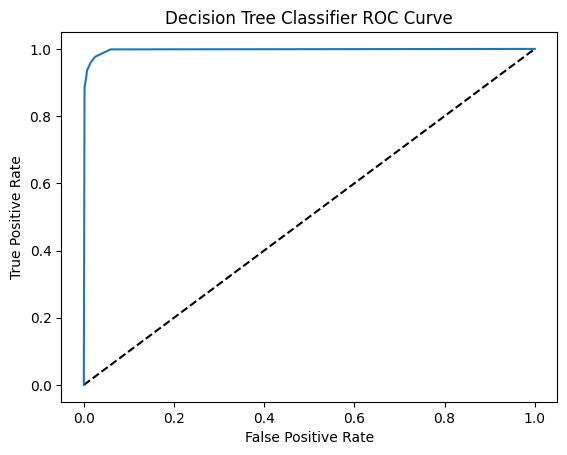

In [137]:
#ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.plot([0,1], [0,1], 'k--')
plt.plot(fpr, tpr, label = 'Decision Tree')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Decision Tree Classifier ROC Curve')
plt.show()

#### 3. Provide the code used to perform the prediction analysis from part D2.

In [138]:
#The below is the same code from D1 and D2. It is restated in order to fulfill the requirement for Section D3.

##Split dataframe into X and y and output X_train, X_test, y_train, y_test files
X = medical_data_encoded.drop('ReAdmis', axis=1)
y = medical_data_encoded['ReAdmis']

#train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1111, stratify = y)

In [139]:
#Output files
X_train.to_csv('X_train.csv', index = False)

In [140]:
X_test.to_csv('X_test.csv', index = False)

In [141]:
y_train.to_csv('y_train.csv', index = False)

In [142]:
y_test.to_csv('y_test.csv', index = False)

In [143]:
#Set up parameters
params = {
    'max_depth': [None, 1, 3, 5 , 7, 10],
    'min_samples_leaf': [1, 2, 3, 4]
    }

#Instantiate DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state = 1111)

#Instantiate GridSearchCV
grid_search = GridSearchCV(dt, params, cv=5, scoring = 'roc_auc', n_jobs = -1)

#Fit GridSearchCV to training data
grid_search.fit(X_train, y_train)

#Find the best estimator
estimator = grid_search.best_estimator_

#Predict test-set labels
initial_y_pred = estimator.predict(X_test)

#Check the accuracy acore
acc_test = accuracy_score(y_test, initial_y_pred)
print('Initial accuracy score: ', acc_test)

Initial accuracy score:  0.9755


In [144]:
#Predict the test set probabilities of the positive class
y_pred_proba = estimator.predict_proba(X_test)[:,1]

#Compute roc_auc
roc_auc = roc_auc_score(y_test, y_pred_proba)

#Print roc_auc
print("Initial AUC score: ", roc_auc)

Initial AUC score:  0.9968097722449648


In [145]:
#Find best parameters
print("Best parameters: ", grid_search.best_params_)

Best parameters:  {'max_depth': 3, 'min_samples_leaf': 2}


In [146]:
#Final DecisionTree setup using defined parameters

#Instantiate DecisionTreeClassifier
dt2 = DecisionTreeClassifier(max_depth = 3, min_samples_leaf = 2, random_state = 1111)

#Fit DecisionTree to the training data
dt2.fit(X_train, y_train)

#Predict the test set probabilities of positive class
y_pred_proba2 = dt2.predict_proba(X_test)[:,1]

#Predict test-set labels
y_pred = dt2.predict(X_test)

#Generate confusion matrix
print("The confusion matrix for the DecisionTree classifier:")
print(confusion_matrix(y_test, y_pred))

The confusion matrix for the DecisionTree classifier:
[[1234   32]
 [  17  717]]


In [147]:
#Generate MSE and RMSE
MSE = mean_squared_error(y_test, y_pred)
RMSE = MSE**(1/2)
print("The mean squared error is:", MSE)
print("The RMSE is:", RMSE)

The mean squared error is: 0.0245
The RMSE is: 0.15652475842498528


In [148]:
#Generate AUC score
print("The Area Under the Curve (AUC) for the DecisionTree classifier:")
print(roc_auc_score(y_test, y_pred_proba2))

The Area Under the Curve (AUC) for the DecisionTree classifier:
0.9968097722449648


In [149]:
#Generate classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1266
           1       0.96      0.98      0.97       734

    accuracy                           0.98      2000
   macro avg       0.97      0.98      0.97      2000
weighted avg       0.98      0.98      0.98      2000



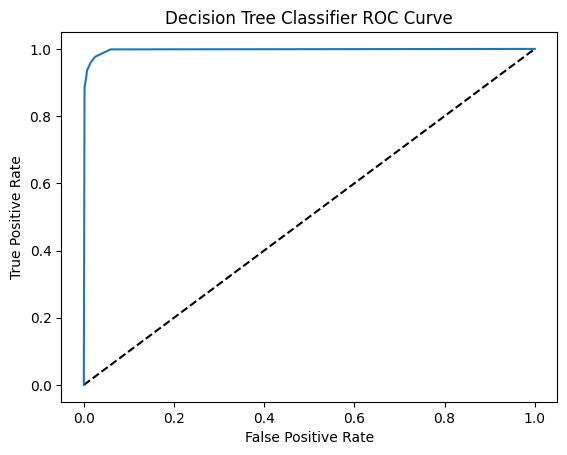

In [150]:
#ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.plot([0,1], [0,1], 'k--')
plt.plot(fpr, tpr, label = 'Decision Tree')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Decision Tree Classifier ROC Curve')
plt.show()

## Part V: Data Summary and Implications

### E. Summarize your data analysis by doing the following:

#### 1. Explain the accuracy and the mean squared error (MSE) of your prediction model.

The mean squared error of the prediction model is roughly 0.02. Frost (n.d.) notes that "Mean squared error (MSE) measures the amount of error in statistical models. It assesses the average squared difference between the observed and predicted values. When a model has no error, the MSE equals zero. As model error increases, its value increases." As MSE measures the amount of error, on the surface it appears that the score of 0.02 for this model is a great result to achieve. However, there is a section of the above quote that demonstrates why this score might not be as useful as it initially appears. The quote notes that MSE assesses the average squared difference between the observed and predicted values, however this is more applicable to when the target variable is continuous, such as in a linear regression. For our classifier, the target values can be either 0 or 1, both of which return their original values when squared. Therefore, squaring the difference does not provide a clear interpretation of the error. In short, while the MSE for this classifier is a low value, other values such as accuracy, precision, or recall will likely provide more applicable insight into the model's performance.

The accuracy for the prediction model is roughly 0.98. Specifically, accuracy measures how many of the data points in the dataset the classification model accurately predicts. From the confusion matrix, we can see how that accuracy score was calculated by remembering that accuracy is (TN+TP)/(TN+TP+FN+FP). From this, the score becomes (1234+717)/(1234+717+17+32), which returns 1951/2000, or roughly .9755. From this score, we can determine that the model is currently doing a very good job of classifying both true positives and true negatives very well.

#### 2. Discuss the results and implications of your prediction analysis.

The results of the decision tree classifier were promising. We can see from the classification report above that the model achieved a score of 0.98 for accuracy, precision, recall, and f1-score. Additionally, the AUC score was roughly 0.997.

Using the GridSearchCV helped identify the ideal parameters for max_depth and min_samples_leaf via cross-validation. Based on the GridSearchCV() results, the ideal values were 3 for max_depth and 2 for min_samples_leaf. 

Initially, either an adaptive booster or a gradient booster was considered, however the model performance without boosting was such that the model was a strong classifier. As boosters are beneficial when the model is a weak predictor and can be computationally intensive, it was determined that a booster would not provide much value.

Based on the scores the model achieved, the implications would be that, on the surface, this classification model is working well. However, the high accuracy and AUC might seem too good to be true, and could indicate that the model would need to be tested on entirely unseen data in order to be revalidated. Overall, testing the model on new data may help to confirm that the initial positive results we achieved are reliable and can be trusted.

#### 3. Discuss one limitation of your data analysis.

One limitation of the data analysis is that many of the variables are not balanced particularly well, which may cause the classifier to be biased. Our target variable, 'ReAdmis', has roughly 34% of patients that were readmitted within one month compared to 66% that were not. Currently, it could be that the classifier is biased in favor of those who were not readmitted. It would be benefifical to have access to a dataset where the breakdown was closer to 50/50 readmitted/not readmitted so that we can identify if the model is biased. This has practical ramifications as well, as it's not certain that the readmission percentage from the 10,000 sample dataset reflects the average readmission rate in reality. If in real life the readmission percentage is closer to 60%, then the model might struggle applying its criteria to a dataset that differs greatly from the one it was tested on. Ideally, a more balanced or representative dataset would reduce the effects of the limitations of this data analysis.

#### 4. Recommend a course of action for the real-world organizational situation from part A1 based on yoru results and implications discussed in part E2.

Based on the decision tree classifier's results and implications discussed in Section D2, this model would likely benefit the organization in terms of classifying whether a patient is readmitted within one month of release. This can be very valuable to an organization, as preemptive attention can be directed toward those most at risk of returning within one month of release.

Before implementing the model, it would benefit the organization to continue to test the model on new data, preferably as different as possible from the initial data. The model performing similarly well on entirely new data would instill confidence that the model is generally applicable.

Overall, the recommended course of action is to re-test the model on new data. Once this has been performed, assess the model's performance to see if it generalizes well to the new data. If it does, it is recommended to use the classification model to identify patients most as risk of being readmitted within one month, and schedule follow-up calls or visits with those patients after one or two weeks. This could help get out in front of any of the issues that would cause someone to be readmitted within one month.

## References

Brownlee, J. (2020, August 14). Boosting and AdaBoost for machine learning. MachineLearningMastery.com.
https://machinelearningmastery.com/boosting-and-adaboost-for-machine-learning/#:~:text=AdaBoost%20can%20be%20used%20to,decision%20trees%20with%20one%20level 

Decision trees. Decision Trees | Data Mining. (n.d.). 
https://pantelis.github.io/cs634/docs/common/lectures/decision-trees/ 

Frost, J. (2023, May 28). Mean squared error (MSE). Statistics By Jim. 
https://statisticsbyjim.com/regression/mean-squared-error-mse/ 

Sehra, C. (2020, November 30). Decision trees explained easily. Medium. 
https://chirag-sehra.medium.com/decision-trees-explained-easily-28f23241248 